/# Задание 2. Линейная регрессия

Что нужно сделать:
- вручную написать простую линейную регрессию: вес человека по росту (датасет 500 Person Gender Height Weight Index);
- вручную написать множественную линейную регрессию: цена дома по его характеристикам (датасет Housing Prices Regression);
- то же самое, но через `LinearRegression` из scikit-learn;
- отложить по 30 объектов, обучиться на остальных и сравнить прогноз с правильными ответами на графике.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)

## Часть 1. Простая линейная регрессия своими руками

Модель: $\hat{y} = w \cdot x + b$, ошибка — MSE: $L = \frac{1}{n}\sum (\hat{y}_i - y_i)^2$.

Производные, по которым идет градиентный спуск:
$\frac{\partial L}{\partial w} = \frac{2}{n}\sum (\hat{y}_i - y_i) x_i$, 
$\frac{\partial L}{\partial b} = \frac{2}{n}\sum (\hat{y}_i - y_i)$.

In [2]:
people = pd.read_csv("500_Person_Gender_Height_Weight_Index.csv")
people.head()

,Gender,Height,Weight,Index
0,Male,174,96,4
1,Male,189,87,2
2,Female,185,110,4
3,Female,195,104,3
4,Male,149,61,3


In [3]:
people.info()
print()
print(people.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Gender  500 non-null    str  
 1   Height  500 non-null    int64
 2   Weight  500 non-null    int64
 3   Index   500 non-null    int64
dtypes: int64(3), str(1)
memory usage: 15.8 KB

Gender    0
Height    0
Weight    0
Index     0
dtype: int64


In [4]:
people.describe()

,Height,Weight,Index
count,500.000000,500.000000,500.000000
mean,169.944000,106.000000,3.748000
std,16.375261,32.382607,1.355053
min,140.000000,50.000000,0.000000
25%,156.000000,80.000000,3.000000
50%,170.500000,106.000000,4.000000
75%,184.000000,136.000000,5.000000
max,199.000000,160.000000,5.000000


## Смотрим на исходные точки

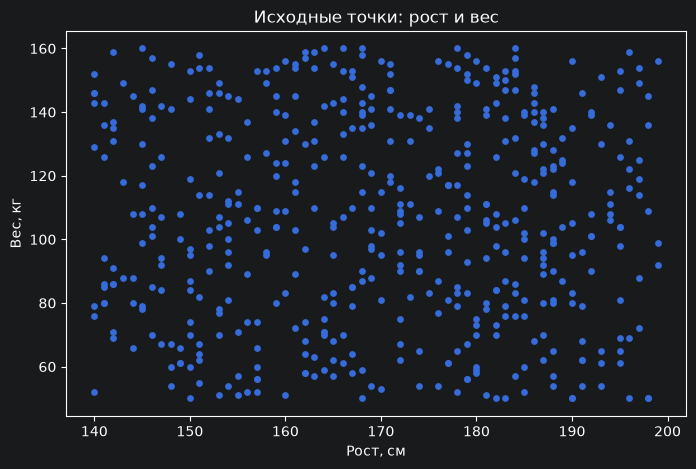

In [5]:
x = people["Height"].values.astype(float)   # рост, см
y = people["Weight"].values.astype(float)   # вес, кг

plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=15)
plt.xlabel("Рост, см")
plt.ylabel("Вес, кг")
plt.title("Исходные точки: рост и вес")
plt.show()

Точки заполняют весь прямоугольник, никакой явной прямой глазами не видно. Но регрессию все равно построим.

Рост измеряется в сантиметрах (числа около 170), и на таких больших значениях градиентный спуск с нормальным
шагом разлетается. Поэтому нормируем признак: $x_{norm} = (x - mean) / std$, а в конце пересчитаем
коэффициенты обратно в исходные единицы.

In [6]:
x_mean = x.mean()
x_std = x.std()
x_norm = (x - x_mean) / x_std

In [7]:
# простая линейная регрессия градиентным спуском (вручную)
def linear_regression_gd(x, y, lr, n_iters):
    w = 0.0
    b = 0.0
    n = len(x)
    losses = []

    for i in range(n_iters):
        y_pred = w * x + b
        error = y_pred - y
        losses.append(np.mean(error ** 2))          # MSE на текущем шаге

        dw = 2 * np.mean(error * x)                 # производная по w
        db = 2 * np.mean(error)                     # производная по b

        w = w - lr * dw
        b = b - lr * db

    return w, b, losses

In [8]:
w_norm, b_norm, losses = linear_regression_gd(x_norm, y, lr=0.1, n_iters=500)

# возвращаемся к исходным единицам: y = w*x + b
w = w_norm / x_std
b = b_norm - w_norm * x_mean / x_std

print("w =", w)
print("b =", b)
print("MSE на последнем шаге =", losses[-1])

w = 0.000881870910361045
b = 105.85013133000957
MSE на последнем шаге = 1046.535791878465


## Регрессионная прямая

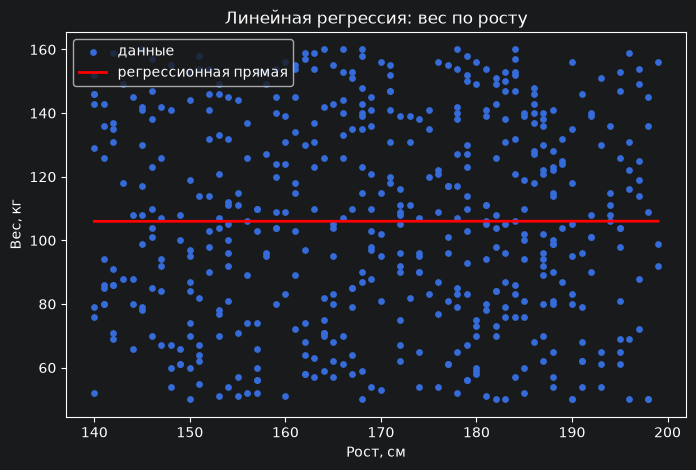

In [9]:
line_x = np.array([x.min(), x.max()])
line_y = w * line_x + b

plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=15, label="данные")
plt.plot(line_x, line_y, color="red", linewidth=2, label="регрессионная прямая")
plt.xlabel("Рост, см")
plt.ylabel("Вес, кг")
plt.title("Линейная регрессия: вес по росту")
plt.legend()
plt.show()

## Спадание функции ошибки

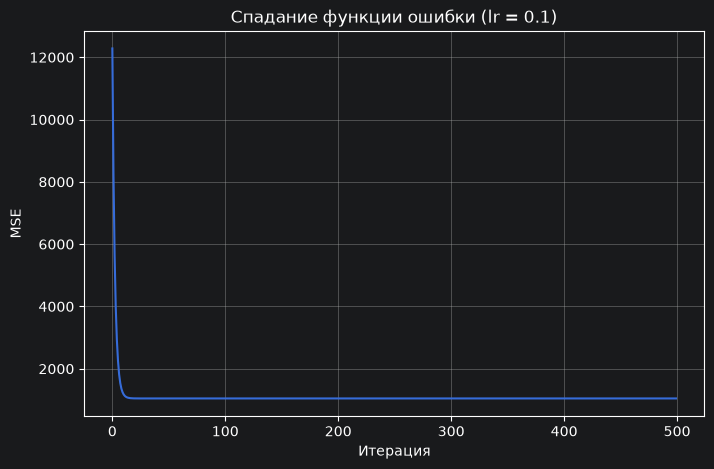

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.xlabel("Итерация")
plt.ylabel("MSE")
plt.title("Спадание функции ошибки (lr = 0.1)")
plt.grid(True)
plt.show()

In [11]:
# коэффициент детерминации, чтобы понять, насколько модель вообще полезна
y_pred = w * x + b
print("R2 =", r2_score(y, y_pred))

R2 = 1.9886705737715005e-07


Ошибка красиво падает за первые несколько десятков итераций и выходит на полку — градиентный спуск сошелся.
Но сама прямая получилась почти горизонтальной, а $R^2 \approx 0$: в этом датасете рост и вес сгенерированы
независимо друг от друга, связи между ними нет. То есть алгоритм отработал правильно и честно нашел лучшую
прямую, просто лучшая прямая здесь — это почти константа, средний вес.

## Часть 2. Множественная линейная регрессия своими руками

Теперь признаков несколько: $\hat{y} = Xw + b$. Формулы те же, только $w$ — вектор, а производная по нему
считается через матричное умножение: $\frac{\partial L}{\partial w} = \frac{2}{n} X^T (\hat{y} - y)$.

In [12]:
houses = pd.read_csv("real_estate_dataset.csv")
houses = houses.drop("ID", axis=1)      # id — просто номер строки, для модели бесполезен
houses.head()

,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
0,143.635030,1,3,3,1967,1,1,48,8.297631,5.935734,602134.816747
1,287.678577,1,2,1,1949,0,1,37,6.061466,10.827392,591425.135386
2,232.998485,1,3,2,1923,1,0,14,2.911442,6.904599,464478.696880
3,199.664621,5,2,2,1918,0,0,17,2.070949,8.284019,583105.655996
4,89.004660,4,3,3,1999,1,0,34,1.523278,14.648277,619879.142523


In [13]:
houses.info()
print()
print(houses.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Square_Feet         500 non-null    float64
 1   Num_Bedrooms        500 non-null    int64  
 2   Num_Bathrooms       500 non-null    int64  
 3   Num_Floors          500 non-null    int64  
 4   Year_Built          500 non-null    int64  
 5   Has_Garden          500 non-null    int64  
 6   Has_Pool            500 non-null    int64  
 7   Garage_Size         500 non-null    int64  
 8   Location_Score      500 non-null    float64
 9   Distance_to_Center  500 non-null    float64
 10  Price               500 non-null    float64
dtypes: float64(4), int64(7)
memory usage: 43.1 KB

Square_Feet           0
Num_Bedrooms          0
Num_Bathrooms         0
Num_Floors            0
Year_Built            0
Has_Garden            0
Has_Pool              0
Garage_Size           0
Location_Score        0
D

In [14]:
# посмотрим, какие признаки вообще связаны с ценой
houses.corr()["Price"].sort_values(ascending=False)

Price                 1.000000
Num_Bedrooms          0.563973
Square_Feet           0.558604
Year_Built            0.418293
Num_Floors            0.177435
Num_Bathrooms         0.156689
Has_Pool              0.136579
Has_Garden            0.109196
Location_Score        0.071326
Garage_Size           0.032100
Distance_to_Center    0.000730
Name: Price, dtype: float64

In [15]:
X = houses.drop("Price", axis=1).values.astype(float)
Y = houses["Price"].values.astype(float)
feature_names = houses.drop("Price", axis=1).columns

# признаки в очень разных масштабах (год постройки ~2000, а Has_Pool это 0/1),
# поэтому опять нормируем
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_norm = (X - X_mean) / X_std

print(X.shape)

(500, 10)


In [16]:
# множественная линейная регрессия градиентным спуском (вручную)
def multiple_linear_regression_gd(X, y, lr, n_iters):
    n, m = X.shape
    w = np.zeros(m)
    b = 0.0
    losses = []

    for i in range(n_iters):
        y_pred = X @ w + b
        error = y_pred - y
        losses.append(np.mean(error ** 2))

        dw = 2 * (X.T @ error) / n
        db = 2 * np.mean(error)

        w = w - lr * dw
        b = b - lr * db

    return w, b, losses

## Сравниваем 3 разных learning rate

In [17]:
learning_rates = [0.001, 0.01, 0.1]
results = {}

for lr in learning_rates:
    w_lr, b_lr, losses_lr = multiple_linear_regression_gd(X_norm, Y, lr=lr, n_iters=500)
    results[lr] = (w_lr, b_lr, losses_lr)
    print("lr =", lr, " MSE на последнем шаге =", losses_lr[-1])

lr = 0.001  MSE на последнем шаге = 48722878422.64571
lr = 0.01  MSE на последнем шаге = 358451395.96207863
lr = 0.1  MSE на последнем шаге = 358450022.4153193


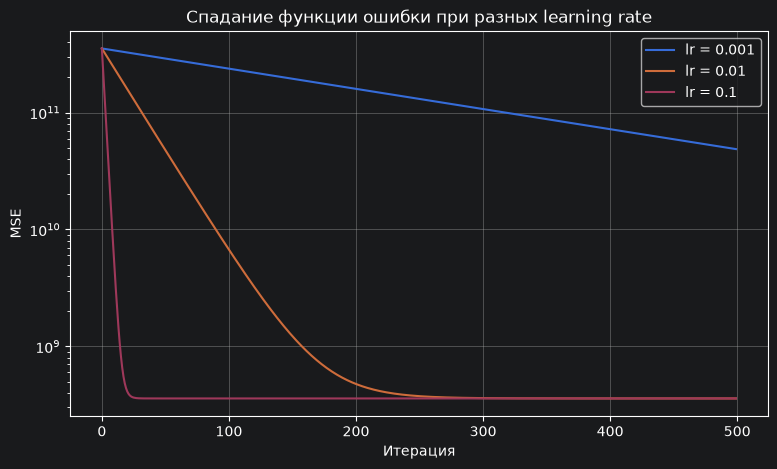

In [18]:
plt.figure(figsize=(9, 5))
for lr in learning_rates:
    plt.plot(results[lr][2], label="lr = " + str(lr))

plt.xlabel("Итерация")
plt.ylabel("MSE")
plt.yscale("log")           # ошибка огромная (цены в сотнях тысяч), без лог-шкалы кривые сливаются
plt.title("Спадание функции ошибки при разных learning rate")
plt.legend()
plt.grid(True)
plt.show()

При `lr = 0.1` ошибка падает быстрее всех и за 500 итераций успевает выйти на минимум.
При `lr = 0.01` спуск идет заметно медленнее, но тоже почти доходит.
При `lr = 0.001` шаг слишком маленький: за те же 500 итераций модель не успевает обучиться и ошибка
остается примерно на два порядка больше. Расхождения нет ни у одного шага, значит все три значения выбраны
безопасно, вопрос только в скорости.

## Коэффициенты регрессии

In [19]:
# берем самый удачный шаг и переводим коэффициенты обратно в исходные единицы измерения
w_norm_h, b_norm_h, _ = results[0.1]

w_house = w_norm_h / X_std
b_house = b_norm_h - np.sum(w_norm_h * X_mean / X_std)

coefs = pd.DataFrame({"признак": feature_names, "коэффициент": w_house})
print("b (свободный член) =", b_house)
coefs

b (свободный член) = -2896629.228557764


,признак,коэффициент
0,Square_Feet,1017.803361
1,Num_Bedrooms,50685.188023
2,Num_Bathrooms,29947.995353
3,Num_Floors,21134.019516
4,Year_Built,1518.241278
5,Has_Garden,30455.502297
6,Has_Pool,47415.253843
7,Garage_Size,1135.277720
8,Location_Score,4805.363416
9,Distance_to_Center,-1944.898185


Коэффициенты читаются так: при `Square_Feet` стоит примерно +1000, значит каждый дополнительный квадратный
фут добавляет к цене около тысячи; лишняя спальня — это плюс 50 тысяч, бассейн — плюс 47 тысяч, а каждый год
"новизны" дома — плюс полторы тысячи. Единственный отрицательный коэффициент у `Distance_to_Center`: чем
дальше дом от центра, тем он дешевле. Все знаки выглядят логично.

## Часть 3. То же самое через LinearRegression из scikit-learn

Здесь ничего вручную считать не надо: класс сам решает задачу аналитически (методом наименьших квадратов),
поэтому и градиентный спуск, и learning rate ему не нужны.

In [20]:
# датасет 1: вес по росту
model_people = LinearRegression()
model_people.fit(x.reshape(-1, 1), y)

print("sklearn:  w =", model_people.coef_[0], " b =", model_people.intercept_)
print("вручную:  w =", w, " b =", b)
print("R2 =", model_people.score(x.reshape(-1, 1), y))

sklearn:  w = 0.0008818709103610113  b = 105.8501313300096
вручную:  w = 0.000881870910361045  b = 105.85013133000957
R2 = 1.9886705737715005e-07


In [21]:
# датасет 2: цена дома
model_houses = LinearRegression()
model_houses.fit(X, Y)

compare = pd.DataFrame({
    "признак": feature_names,
    "вручную": w_house,
    "sklearn": model_houses.coef_,
})
print("b вручную =", b_house)
print("b sklearn =", model_houses.intercept_)
print("R2 =", model_houses.score(X, Y))
compare

b вручную = -2896629.228557764
b sklearn = -2896629.228557742
R2 = 0.9759766171790658


,признак,вручную,sklearn
0,Square_Feet,1017.803361,1017.803361
1,Num_Bedrooms,50685.188023,50685.188023
2,Num_Bathrooms,29947.995353,29947.995353
3,Num_Floors,21134.019516,21134.019516
4,Year_Built,1518.241278,1518.241278
5,Has_Garden,30455.502297,30455.502297
6,Has_Pool,47415.253843,47415.253843
7,Garage_Size,1135.277720,1135.277720
8,Location_Score,4805.363416,4805.363416
9,Distance_to_Center,-1944.898185,-1944.898185


Коэффициенты, полученные градиентным спуском вручную, практически совпали с тем, что выдал scikit-learn —
значит, своя реализация написана верно. Небольшая разница остается только там, где градиентный спуск за
500 итераций не дошел до точного минимума. По $R^2$: для домов модель объясняет около 98% разброса цены,
а для роста/веса — примерно 0%, то есть линейная регрессия там бессильна не из-за алгоритма, а из-за данных.

## Часть 4. Откладываем 30 объектов и проверяем прогноз

Порядок такой: сначала делим выборку на обучающую и отложенные 30 объектов, потом считаем параметры
нормировки **только по обучающей части** и применяем их к обеим — иначе информация о тесте протечет в обучение.

In [22]:
# небольшая функция, чтобы не писать метрики два раза
def print_metrics(y_true, y_pred):
    print("MAE  =", mean_absolute_error(y_true, y_pred))
    print("MSE  =", mean_squared_error(y_true, y_pred))
    print("RMSE =", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2   =", r2_score(y_true, y_pred))

### Датасет 1: вес по росту

In [23]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=30, random_state=42)
print(len(x_train), len(x_test))

470 30


In [24]:
# своя реализация: нормировку считаем по обучающей части
x_tr_mean = x_train.mean()
x_tr_std = x_train.std()

w_n, b_n, _ = linear_regression_gd((x_train - x_tr_mean) / x_tr_std, y_train, lr=0.1, n_iters=500)
w_my = w_n / x_tr_std
b_my = b_n - w_n * x_tr_mean / x_tr_std

pred_my = w_my * x_test + b_my

# и то же самое через sklearn
model = LinearRegression()
model.fit(x_train.reshape(-1, 1), y_train)
pred_sk = model.predict(x_test.reshape(-1, 1))

print("--- своя реализация ---")
print_metrics(y_test, pred_my)
print()
print("--- sklearn ---")
print_metrics(y_test, pred_sk)

--- своя реализация ---
MAE  = 26.98835080997254
MSE  = 1017.8971105538283
RMSE = 31.904499848043823
R2   = -0.06043099787874451

--- sklearn ---
MAE  = 26.98835080997254
MSE  = 1017.897110553828
RMSE = 31.90449984804382
R2   = -0.060430997878744286


In [25]:
pd.DataFrame({
    "правильный ответ": y_test,
    "прогноз": pred_sk.round(2),
    "разница": (y_test - pred_sk).round(2),
}).head(10)

,правильный ответ,прогноз,разница
0,103.0,105.19,-2.19
1,75.0,106.07,-31.07
2,95.0,105.80,-10.80
3,103.0,106.03,-3.03
4,140.0,106.63,33.37
5,154.0,104.77,49.23
6,142.0,105.98,36.02
7,149.0,105.05,43.95
8,82.0,105.33,-23.33
9,157.0,105.24,51.76


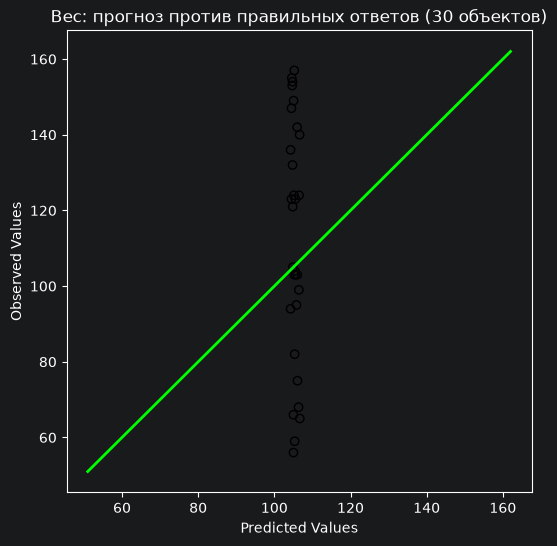

In [26]:
plt.figure(figsize=(6, 6))
plt.scatter(pred_sk, y_test, facecolors="none", edgecolors="black")

lims = [min(pred_sk.min(), y_test.min()) - 5, max(pred_sk.max(), y_test.max()) + 5]
plt.plot(lims, lims, color="lime", linewidth=2)

plt.xlabel("Predicted Values")
plt.ylabel("Observed Values")
plt.title("Вес: прогноз против правильных ответов (30 объектов)")
plt.show()

Все прогнозы собрались в узкую вертикальную полоску около 106 кг (это средний вес по обучающей выборке),
а настоящие значения разбросаны от 50 до 160. Точки не ложатся на зеленую прямую, $R^2$ на тесте
отрицательный — модель не лучше, чем просто предсказывать среднее. Ожидаемо: связи роста и веса в этом
датасете нет, предсказывать не по чему.

### Датасет 2: цена дома

In [27]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=30, random_state=42)
print(X_train.shape, X_test.shape)

(470, 10) (30, 10)


In [28]:
# нормировка снова только по обучающей части
X_tr_mean = X_train.mean(axis=0)
X_tr_std = X_train.std(axis=0)

w_n, b_n, _ = multiple_linear_regression_gd((X_train - X_tr_mean) / X_tr_std, Y_train, lr=0.1, n_iters=500)
pred_my = ((X_test - X_tr_mean) / X_tr_std) @ w_n + b_n

model = LinearRegression()
model.fit(X_train, Y_train)
pred_sk = model.predict(X_test)

print("--- своя реализация ---")
print_metrics(Y_test, pred_my)
print()
print("--- sklearn ---")
print_metrics(Y_test, pred_sk)

--- своя реализация ---
MAE  = 15741.572341970686
MSE  = 354336890.41849405
RMSE = 18823.83835508832
R2   = 0.979353228278203

--- sklearn ---
MAE  = 15741.572341970694
MSE  = 354336890.41849464
RMSE = 18823.838355088334
R2   = 0.979353228278203


In [29]:
pd.DataFrame({
    "правильный ответ": Y_test.round(2),
    "прогноз": pred_sk.round(2),
    "разница": (Y_test - pred_sk).round(2),
}).head(10)

,правильный ответ,прогноз,разница
0,591058.71,575089.39,15969.32
1,667693.00,680732.34,-13039.34
2,532377.58,496923.16,35454.42
3,478489.30,479384.48,-895.18
4,730197.48,708546.40,21651.08
5,515544.25,533138.10,-17593.85
6,354991.35,363864.87,-8873.52
7,573486.15,566729.70,6756.45
8,529467.60,558231.09,-28763.50
9,739265.74,717276.10,21989.64


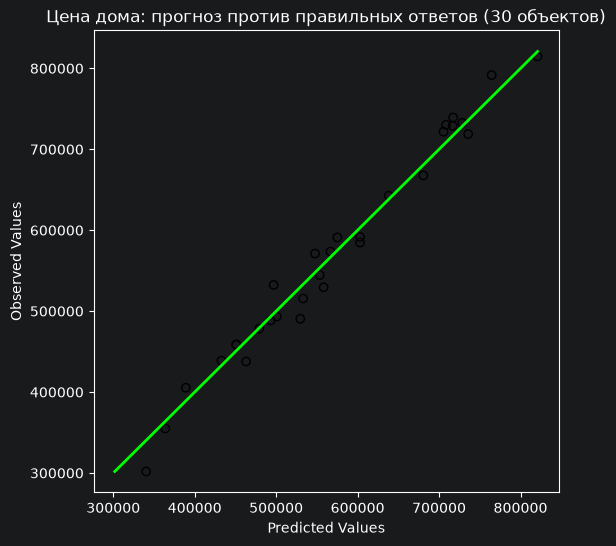

In [30]:
plt.figure(figsize=(6, 6))
plt.scatter(pred_sk, Y_test, facecolors="none", edgecolors="black")

lims = [min(pred_sk.min(), Y_test.min()), max(pred_sk.max(), Y_test.max())]
plt.plot(lims, lims, color="lime", linewidth=2)

plt.xlabel("Predicted Values")
plt.ylabel("Observed Values")
plt.title("Цена дома: прогноз против правильных ответов (30 объектов)")
plt.show()

Здесь картинка совсем другая: точки лежат вплотную к зеленой прямой, то есть прогноз почти совпадает с
правильным ответом. $R^2$ на отложенных объектах примерно такой же, как на обучающих, значит модель не
переобучилась и нормально работает на новых данных. Средняя ошибка (MAE) — порядка 15 тысяч при ценах
в районе 580 тысяч, это меньше 3%.

**Общий вывод.** Своя реализация линейной регрессии на градиентном спуске дает те же коэффициенты, что и
`LinearRegression` из scikit-learn, а качество модели определяется не алгоритмом, а данными: там, где связь
между признаками и целевой переменной есть (цены домов), линейная регрессия работает отлично, а там, где
признаки независимы (рост и вес), она честно вырождается в предсказание среднего.